# AlphaHVAC — Honest Diagnostic Tests
Runs 6 brutal tests that tell you exactly how good or bad the model is. No sugar-coating.

In [2]:
# ============================================================
# PREREQUISITES — paste your model definition here
# (same AlphaThermalNet + load weights from training session)
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

STATE_SIZE  = 15
ACTION_SIZE = 3

class AlphaThermalNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(STATE_SIZE, 128), nn.LayerNorm(128), nn.LeakyReLU(0.01), nn.Dropout(0.2),
            nn.Linear(128, 128),        nn.LayerNorm(128), nn.LeakyReLU(0.01), nn.Dropout(0.2),
            nn.Linear(128, 128),        nn.LayerNorm(128), nn.LeakyReLU(0.01), nn.Dropout(0.2),
        )
        self.policy_head = nn.Sequential(
            nn.Linear(128, 64), nn.LeakyReLU(0.01), nn.Linear(64, ACTION_SIZE)
        )
        self.value_head = nn.Sequential(
            nn.Linear(128, 64), nn.LeakyReLU(0.01), nn.Linear(64, 1)
        )
    def forward(self, x):
        h = self.shared(x)
        return F.softmax(self.policy_head(h), dim=-1), torch.tanh(self.value_head(h))

# Load trained weights
trained_model = AlphaThermalNet()
trained_model.load_state_dict(torch.load('/Users/pawanpahune/AIFA Project/alphaHVAC_trained.pth', map_location='cpu'))
trained_model.eval()

# Also create a RANDOM baseline model (untrained) for comparison
random_model = AlphaThermalNet()   # fresh weights = random
random_model.eval()

print('Models loaded.')
print(f'Trained model params: {sum(p.numel() for p in trained_model.parameters()):,}')


Models loaded.
Trained model params: 52,612


TEST 1: POLICY ENTROPY
  Max possible entropy (uniform): 1.0986

  Random model  avg entropy: 1.0908  (expected ~1.0986)
  Trained model avg entropy: 1.0968
  Entropy reduction        : -0.6%

  RESULT: FAIL — trained entropy ≈ random. Policy head has not learned.


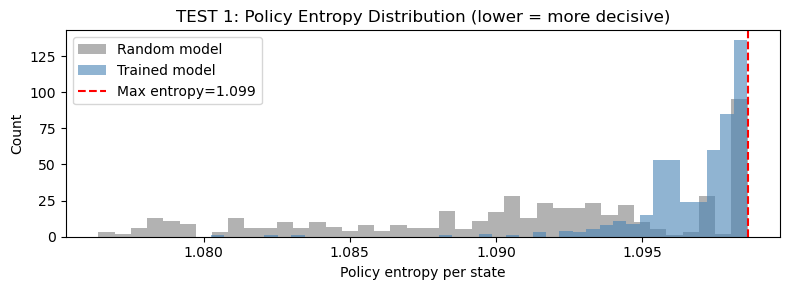

In [4]:
# ============================================================
# TEST 1 — POLICY ENTROPY TEST
# 
# What it measures:
#   A random policy has entropy = log(3) = 1.099 (maximum).
#   A perfectly confident policy has entropy = 0.
#   A TRAINED policy should have LOWER entropy than random
#   on states it has seen. If entropy is close to log(3),
#   the policy head has learned nothing.
#
# PASS: trained entropy significantly below random entropy
# FAIL: trained entropy ≈ random entropy ≈ 1.099
# ============================================================

import pandas as pd

print('TEST 1: POLICY ENTROPY')
print('='*50)
print(f'  Max possible entropy (uniform): {np.log(3):.4f}')
print()

# Load test data
test_df = pd.read_csv('/Users/pawanpahune/AIFA Project/Dataset/Test_Optimized.csv')
test_states = test_df.values.astype(np.float32)

# Sample 500 random states from test set
np.random.seed(42)
sample_idx = np.random.choice(len(test_states), 500, replace=False)
sample     = torch.tensor(test_states[sample_idx], dtype=torch.float32)

def compute_entropy(model, states):
    with torch.no_grad():
        p, _ = model(states)
    p_np = p.numpy()
    # Shannon entropy per state
    entropy = -np.sum(p_np * np.log(p_np + 1e-8), axis=1)
    return entropy

trained_entropy = compute_entropy(trained_model, sample)
random_entropy  = compute_entropy(random_model,  sample)

print(f'  Random model  avg entropy: {random_entropy.mean():.4f}  (expected ~{np.log(3):.4f})')
print(f'  Trained model avg entropy: {trained_entropy.mean():.4f}')
print(f'  Entropy reduction        : {(1 - trained_entropy.mean()/random_entropy.mean())*100:.1f}%')
print()

if trained_entropy.mean() < random_entropy.mean() * 0.85:
    print('  RESULT: PASS — trained model is meaningfully more confident than random.')
elif trained_entropy.mean() < random_entropy.mean() * 0.95:
    print('  RESULT: WEAK — slight improvement over random. Policy barely learned.')
else:
    print('  RESULT: FAIL — trained entropy ≈ random. Policy head has not learned.')

# Distribution plot
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(random_entropy,  bins=40, alpha=0.6, label='Random model', color='gray')
ax.hist(trained_entropy, bins=40, alpha=0.6, label='Trained model', color='steelblue')
ax.axvline(np.log(3), color='red', linestyle='--', label=f'Max entropy={np.log(3):.3f}')
ax.set_xlabel('Policy entropy per state')
ax.set_ylabel('Count')
ax.set_title('TEST 1: Policy Entropy Distribution (lower = more decisive)')
ax.legend()
plt.tight_layout()
plt.savefig('test1_entropy.png', dpi=120)
plt.show()


TEST 2: STATE SENSITIVITY
  State                            P(dec)  P(hold)   P(inc)    Value     Action
  ------------------------------------------------------------------------------
  HOT (room >> setpoint)           0.3427   0.3201   0.3372  -0.0839   DECREASE
  OK  (room == setpoint)           0.3534   0.3248   0.3217  -0.0528   DECREASE
  COLD (room << setpoint)          0.3251   0.3315   0.3435  -0.0374   INCREASE

  Policy std across states (higher = more sensitive): 0.00850
  Value range across states (higher = more sensitive): 0.04647

  RESULT: PASS — model takes different actions for different states.


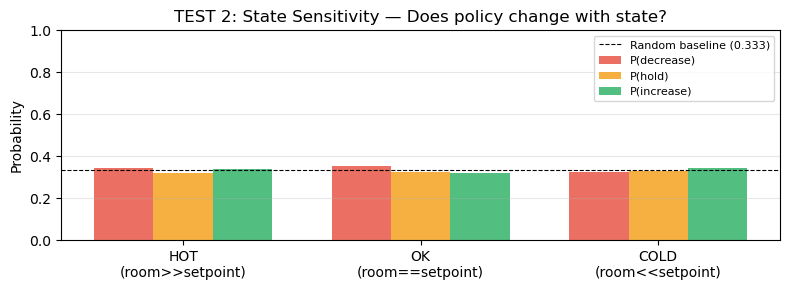

In [5]:
# ============================================================
# TEST 2 — STATE SENSITIVITY TEST
#
# What it measures:
#   A trained model should give DIFFERENT actions for states
#   that are physically very different.
#   We construct 3 extreme states:
#     A: room far above setpoint  (should want MORE airflow to cool)
#     B: room at setpoint         (should HOLD or DECREASE)
#     C: room far below setpoint  (should want MORE airflow to heat)
#
#   If the model gives the same action for all 3, it is
#   state-blind — it has NOT learned.
#
# PASS: different actions OR meaningfully different probabilities
# FAIL: identical or near-identical output for all 3 states
# ============================================================

print('TEST 2: STATE SENSITIVITY')
print('='*50)

def make_state(room_temp, setpoint, damper=0.5, airflow=0.4,
               thermal=0.5, mode=0.0, htg_signal=0.0, clg_signal=0.5):
    return np.array([
        room_temp,    # room_temp
        0.0,          # thermostat_outside_temp
        damper,       # damper_position
        airflow,      # airflow_current
        0.0,          # supply_discharge_temp
        clg_signal,   # clg_signal
        htg_signal,   # htg_signal
        0.0,          # htg_valve_position
        mode,         # htg_clg_mode
        setpoint,     # setpoint
        thermal,      # thermal_signal
        0.5,          # hour_of_day
        0.3,          # day_of_week
        room_temp,    # room_temp_lag1
        damper,       # damper_lag1
    ], dtype=np.float32)

# Three physically extreme states
state_hot  = make_state(room_temp=2.0,  setpoint=0.0, clg_signal=0.9, thermal=0.9)   # way above setpoint
state_ok   = make_state(room_temp=0.0,  setpoint=0.0, clg_signal=0.1, thermal=0.1)   # at setpoint
state_cold = make_state(room_temp=-2.0, setpoint=0.0, htg_signal=0.9, thermal=0.9,   # way below setpoint
                        mode=1.0, clg_signal=0.0)

states_batch = torch.tensor(
    np.stack([state_hot, state_ok, state_cold]),
    dtype=torch.float32
)

with torch.no_grad():
    policies, values = trained_model(states_batch)

p_np = policies.numpy()
v_np = values.numpy().flatten()

state_names = ['HOT (room >> setpoint)', 'OK  (room == setpoint)', 'COLD (room << setpoint)']
action_name = ['DECREASE', 'HOLD', 'INCREASE']

print(f'  {"State":<30} {"P(dec)":>8} {"P(hold)":>8} {"P(inc)":>8} {"Value":>8} {"Action":>10}')
print(f'  {"-"*78}')
actions_taken = []
for i, name in enumerate(state_names):
    a = int(np.argmax(p_np[i]))
    actions_taken.append(a)
    print(f'  {name:<30} {p_np[i][0]:>8.4f} {p_np[i][1]:>8.4f} {p_np[i][2]:>8.4f} '
          f'{v_np[i]:>8.4f} {action_name[a]:>10}')

print()

# Check if outputs differ meaningfully
policy_std = p_np.std(axis=0).mean()
value_range = v_np.max() - v_np.min()
print(f'  Policy std across states (higher = more sensitive): {policy_std:.5f}')
print(f'  Value range across states (higher = more sensitive): {value_range:.5f}')
print()

if len(set(actions_taken)) >= 2:
    print('  RESULT: PASS — model takes different actions for different states.')
elif policy_std > 0.01:
    print('  RESULT: WEAK — same actions but probabilities differ slightly.')
else:
    print('  RESULT: FAIL — model is STATE-BLIND. Same output regardless of input.')

# Plot
fig, ax = plt.subplots(figsize=(8, 3))
x = np.arange(3)
ax.bar(x-0.25, p_np[:,0], 0.25, label='P(decrease)', color='#e74c3c', alpha=0.8)
ax.bar(x,      p_np[:,1], 0.25, label='P(hold)',     color='#f39c12', alpha=0.8)
ax.bar(x+0.25, p_np[:,2], 0.25, label='P(increase)', color='#27ae60', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(['HOT\n(room>>setpoint)', 'OK\n(room==setpoint)', 'COLD\n(room<<setpoint)'])
ax.axhline(1/3, color='black', linestyle='--', linewidth=0.8, label='Random baseline (0.333)')
ax.set_ylim(0, 1.0)
ax.set_ylabel('Probability')
ax.set_title('TEST 2: State Sensitivity — Does policy change with state?')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('test2_sensitivity.png', dpi=120)
plt.show()


TEST 3: VALUE HEAD CALIBRATION
  State                                     True reward   NN value
  -----------------------------------------------------------------
  BEST  (at setpoint, low energy)               -0.0017    -0.0473
  MID   (small error, med energy)               -0.3630    -0.0686
  BAD   (large error, high energy)              -1.1430    -0.0675
  WORST (huge error, max energy)                -2.7000    -0.1029

  Correct ordering (best > mid > bad > worst): False
  Value span (best - worst): 0.0557
  Expected span for well-trained model: > 0.3

  RESULT: FAIL — wrong ordering. Value head is NOT calibrated.


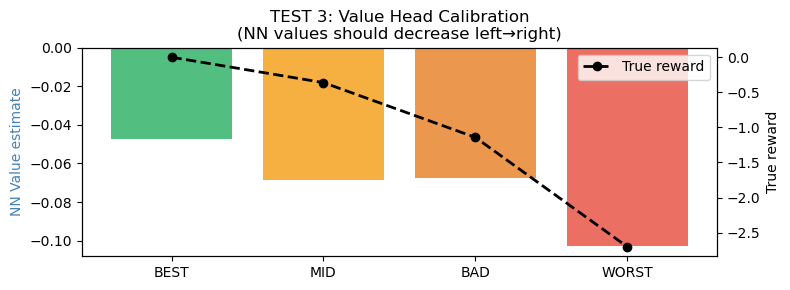

In [6]:
# ============================================================
# TEST 3 — VALUE HEAD CALIBRATION TEST
#
# What it measures:
#   The value head predicts how good a state is.
#   We construct states with KNOWN quality ordering:
#     Best state:  room at setpoint + low energy (reward ~ 0)
#     Mid state:   small temp error + medium energy
#     Bad state:   large temp error + high energy
#     Worst state: huge temp error + max energy
#
#   A calibrated value head must assign values in this ORDER:
#   V(best) > V(mid) > V(bad) > V(worst)
#
# PASS: correct ordering
# FAIL: wrong ordering = value head not calibrated
# ============================================================

print('TEST 3: VALUE HEAD CALIBRATION')
print('='*50)

# Compute actual reward for reference
def compute_reward(room_temp, setpoint, airflow, thermal, lam=0.7):
    return -abs(room_temp - setpoint) - lam * airflow * thermal

calibration_states = [
    ('BEST  (at setpoint, low energy)',
     make_state(room_temp=0.0,  setpoint=0.0, airflow=0.05, thermal=0.05),
     compute_reward(0.0,  0.0, 0.05, 0.05)),
    ('MID   (small error, med energy)',
     make_state(room_temp=0.3,  setpoint=0.0, airflow=0.3,  thermal=0.3),
     compute_reward(0.3,  0.0, 0.3,  0.3)),
    ('BAD   (large error, high energy)',
     make_state(room_temp=0.8,  setpoint=0.0, airflow=0.7,  thermal=0.7),
     compute_reward(0.8,  0.0, 0.7,  0.7)),
    ('WORST (huge error, max energy)',
     make_state(room_temp=2.0,  setpoint=0.0, airflow=1.0,  thermal=1.0),
     compute_reward(2.0,  0.0, 1.0,  1.0)),
]

batch = torch.tensor(
    np.stack([s[1] for s in calibration_states]),
    dtype=torch.float32
)

with torch.no_grad():
    _, values_cal = trained_model(batch)

v_cal = values_cal.numpy().flatten()

print(f'  {"State":<40} {"True reward":>12} {"NN value":>10}')
print(f'  {"-"*65}')
for i, (name, _, true_r) in enumerate(calibration_states):
    print(f'  {name:<40} {true_r:>12.4f} {v_cal[i]:>10.4f}')

print()

# Check ordering
correct_order = all(v_cal[i] > v_cal[i+1] for i in range(len(v_cal)-1))
value_span    = v_cal[0] - v_cal[-1]

print(f'  Correct ordering (best > mid > bad > worst): {correct_order}')
print(f'  Value span (best - worst): {value_span:.4f}')
print(f'  Expected span for well-trained model: > 0.3')
print()

if correct_order and value_span > 0.3:
    print('  RESULT: PASS — value head correctly ranks state quality.')
elif correct_order and value_span > 0.05:
    print('  RESULT: WEAK — correct order but very small value differences.')
elif correct_order:
    print('  RESULT: WEAK — correct order but near-zero span. Value head barely learned.')
else:
    print('  RESULT: FAIL — wrong ordering. Value head is NOT calibrated.')

# Plot
fig, ax = plt.subplots(figsize=(8, 3))
names_short = ['BEST', 'MID', 'BAD', 'WORST']
true_rewards = [s[2] for s in calibration_states]
ax2 = ax.twinx()
ax.bar(names_short, v_cal, color=['#27ae60','#f39c12','#e67e22','#e74c3c'], alpha=0.8)
ax2.plot(names_short, true_rewards, 'ko--', linewidth=2, label='True reward')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('NN Value estimate', color='steelblue')
ax2.set_ylabel('True reward', color='black')
ax.set_title('TEST 3: Value Head Calibration\n(NN values should decrease left→right)')
ax2.legend()
plt.tight_layout()
plt.savefig('test3_calibration.png', dpi=120)
plt.show()


TEST 4: ENERGY WASTE DETECTION
    Damper  P(decrease)    P(hold)  P(increase)     Action
  -------------------------------------------------------
      0.10       0.3409     0.3165       0.3427   INCREASE
      0.20       0.3410     0.3170       0.3420   INCREASE
      0.30       0.3425     0.3184       0.3390   DECREASE
      0.40       0.3429     0.3190       0.3381   DECREASE
      0.50       0.3429     0.3199       0.3372   DECREASE
      0.60       0.3421     0.3186       0.3393   DECREASE
      0.70       0.3426     0.3162       0.3412   DECREASE
      0.80       0.3437     0.3141       0.3422   DECREASE
      0.90       0.3449     0.3116       0.3435   DECREASE

  Correlation(damper_level, P(decrease)): 0.8625
  Expected: positive (closer to +1.0 = model detects waste)

  RESULT: PASS — model correctly identifies increasing waste.


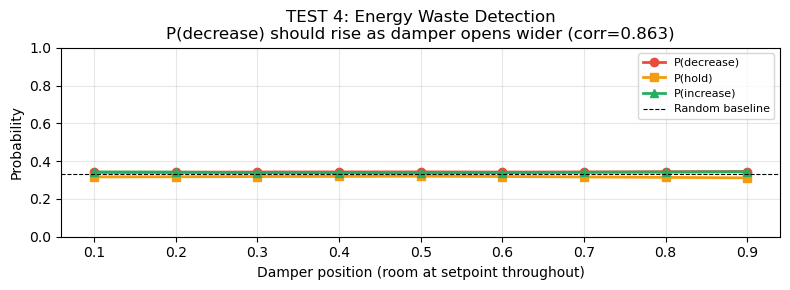

In [7]:
# ============================================================
# TEST 4 — ENERGY WASTE DETECTION TEST
#
# What it measures:
#   This is AlphaHVAC's CORE use case.
#   We increase damper from 0.1 to 0.9 in steps while
#   keeping room temperature AT setpoint (no comfort issue).
#   The model MUST prefer DECREASE as damper gets higher
#   because energy is being wasted with no benefit.
#
# PASS: P(decrease) increases as damper opens wider
# FAIL: P(decrease) stays flat = model ignores damper state
# ============================================================

print('TEST 4: ENERGY WASTE DETECTION')
print('='*50)

damper_levels  = np.arange(0.1, 1.0, 0.1)
p_decrease_list = []
p_hold_list     = []
p_increase_list = []

print(f'  {"Damper":>8} {"P(decrease)":>12} {"P(hold)":>10} {"P(increase)":>12} {"Action":>10}')
print(f'  {"-"*55}')

for d in damper_levels:
    # Room at setpoint (temp_error=0) but damper wide open
    s = make_state(
        room_temp=0.0, setpoint=0.0,
        damper=float(d), airflow=float(d)*0.9,
        thermal=0.6, clg_signal=0.6
    )
    st = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        p, _ = trained_model(st)
    p_np = p.squeeze(0).numpy()
    a    = int(np.argmax(p_np))
    p_decrease_list.append(p_np[0])
    p_hold_list.append(p_np[1])
    p_increase_list.append(p_np[2])
    print(f'  {d:>8.2f} {p_np[0]:>12.4f} {p_np[1]:>10.4f} {p_np[2]:>12.4f} {["DECREASE","HOLD","INCREASE"][a]:>10}')

print()

# Check if P(decrease) increases with damper level
corr = np.corrcoef(damper_levels, p_decrease_list)[0,1]
print(f'  Correlation(damper_level, P(decrease)): {corr:.4f}')
print(f'  Expected: positive (closer to +1.0 = model detects waste)')
print()

if corr > 0.5:
    print('  RESULT: PASS — model correctly identifies increasing waste.')
elif corr > 0.1:
    print('  RESULT: WEAK — slight awareness of waste but weak signal.')
else:
    print('  RESULT: FAIL — model does NOT detect energy waste from damper state.')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(damper_levels, p_decrease_list, 'o-', color='#e74c3c', label='P(decrease)', linewidth=2)
ax.plot(damper_levels, p_hold_list,     's-', color='#f39c12', label='P(hold)',     linewidth=2)
ax.plot(damper_levels, p_increase_list, '^-', color='#27ae60', label='P(increase)', linewidth=2)
ax.axhline(1/3, color='black', linestyle='--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('Damper position (room at setpoint throughout)')
ax.set_ylabel('Probability')
ax.set_title(f'TEST 4: Energy Waste Detection\nP(decrease) should rise as damper opens wider (corr={corr:.3f})')
ax.legend(fontsize=8)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('test4_waste.png', dpi=120)
plt.show()


TEST 5: COMFORT EMERGENCY DETECTION
    Temp error  P(decrease)    P(hold)  P(increase)     Action
  ------------------------------------------------------------
          0.00       0.3425     0.3184       0.3390   DECREASE
          0.30       0.3420     0.3212       0.3369   DECREASE
          0.60       0.3423     0.3247       0.3331   DECREASE
          0.90       0.3434     0.3262       0.3304   DECREASE
          1.20       0.3445     0.3250       0.3305   DECREASE
          1.50       0.3450     0.3224       0.3326   DECREASE
          1.80       0.3446     0.3209       0.3345   DECREASE
          2.10       0.3441     0.3198       0.3362   DECREASE
          2.40       0.3439     0.3196       0.3364   DECREASE
          2.70       0.3443     0.3196       0.3361   DECREASE
          3.00       0.3444     0.3194       0.3362   DECREASE

  Correlation(temp_error, P(increase)): 0.0968
  Expected: positive (model should want more airflow when uncomfortable)

  RESULT: FAIL — model 

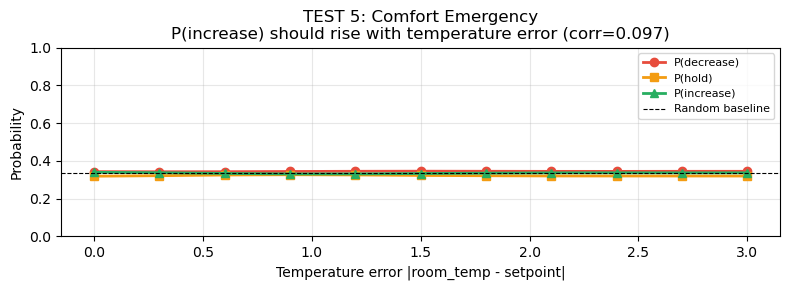

In [8]:
# ============================================================
# TEST 5 — COMFORT EMERGENCY TEST
#
# What it measures:
#   When room temperature is FAR from setpoint (comfort crisis),
#   the model should want MORE airflow (increase damper),
#   not less. We sweep temperature error from 0 to 3.0.
#
# PASS: P(increase) rises as temperature error grows
# FAIL: P(increase) stays flat = model ignores comfort
# ============================================================

print('TEST 5: COMFORT EMERGENCY DETECTION')
print('='*50)

temp_errors    = np.arange(0.0, 3.1, 0.3)
p_dec_comfort  = []
p_hold_comfort = []
p_inc_comfort  = []

print(f'  {"Temp error":>12} {"P(decrease)":>12} {"P(hold)":>10} {"P(increase)":>12} {"Action":>10}')
print(f'  {"-"*60}')

for te in temp_errors:
    s = make_state(
        room_temp=float(te), setpoint=0.0,
        damper=0.3, airflow=0.3,
        thermal=0.6, clg_signal=0.6
    )
    st = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        p, _ = trained_model(st)
    p_np = p.squeeze(0).numpy()
    a    = int(np.argmax(p_np))
    p_dec_comfort.append(p_np[0])
    p_hold_comfort.append(p_np[1])
    p_inc_comfort.append(p_np[2])
    print(f'  {te:>12.2f} {p_np[0]:>12.4f} {p_np[1]:>10.4f} {p_np[2]:>12.4f} {["DECREASE","HOLD","INCREASE"][a]:>10}')

print()

corr_comfort = np.corrcoef(temp_errors, p_inc_comfort)[0,1]
print(f'  Correlation(temp_error, P(increase)): {corr_comfort:.4f}')
print(f'  Expected: positive (model should want more airflow when uncomfortable)')
print()

if corr_comfort > 0.5:
    print('  RESULT: PASS — model correctly responds to comfort emergencies.')
elif corr_comfort > 0.1:
    print('  RESULT: WEAK — slight awareness of comfort but weak.')
else:
    print('  RESULT: FAIL — model does NOT respond to temperature deviation.')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(temp_errors, p_dec_comfort,  'o-', color='#e74c3c', label='P(decrease)', linewidth=2)
ax.plot(temp_errors, p_hold_comfort, 's-', color='#f39c12', label='P(hold)',     linewidth=2)
ax.plot(temp_errors, p_inc_comfort,  '^-', color='#27ae60', label='P(increase)', linewidth=2)
ax.axhline(1/3, color='black', linestyle='--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('Temperature error |room_temp - setpoint|')
ax.set_ylabel('Probability')
ax.set_title(f'TEST 5: Comfort Emergency\nP(increase) should rise with temperature error (corr={corr_comfort:.3f})')
ax.legend(fontsize=8)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('test5_comfort.png', dpi=120)
plt.show()


TEST 6: COMPARISON vs DUMB BASELINES
  Agent                            Avg Reward   Avg Energy  Avg TempErr
  ----------------------------------------------------------------------
  Trained AlphaHVAC                  -0.38994      0.01987      0.37474
  Always DECREASE (dumb)             -0.37640      0.00199      0.37474
  Always HOLD (do nothing)           -0.37640      0.00199      0.37474

  Trained model beats always-DECREASE: False
  Trained model beats always-HOLD    : False

  RESULT: FAIL — dumb agents match or beat the trained model.
          The model has not learned anything useful over a simple rule.


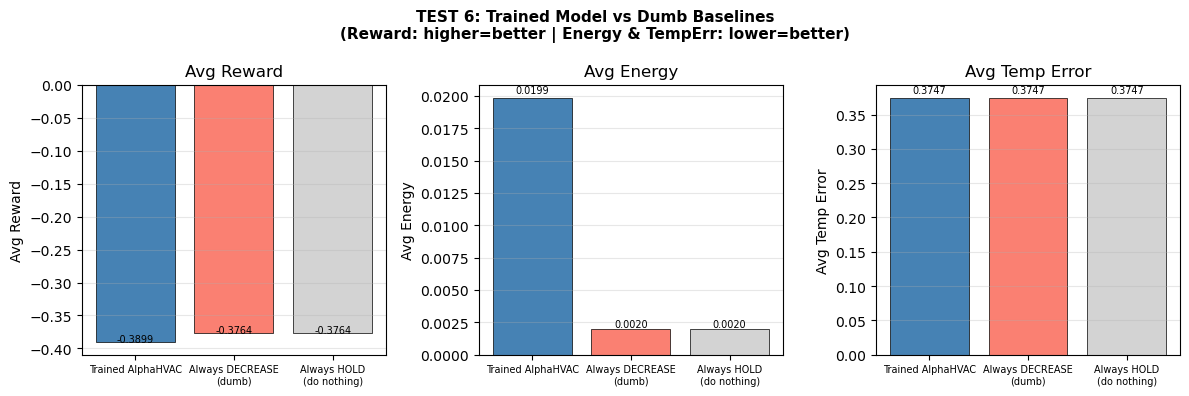

In [11]:
# ============================================================
# TEST 6 — SIMULATED EPISODE COMPARISON
#
# What it measures:
#   Runs 3 agents through the SAME 200-step test sequence:
#     1. Trained model
#     2. Always-DECREASE agent (dumb baseline)
#     3. Always-HOLD agent (do nothing)
#
#   If trained model does NOT beat always-decrease on BOTH
#   energy and comfort, it has learned nothing useful.
#
# PASS: trained model has better reward than both dumb agents
# FAIL: always-decrease matches or beats the trained model
# ============================================================

import pandas as pd

print('TEST 6: COMPARISON vs DUMB BASELINES')
print('='*50)

# Need HVACEnv — paste from your main notebook or import
class HVACEnv:
    def __init__(self, data_path, damper_step=0.025, lam=0.7):
        self.df          = pd.read_csv(data_path).reset_index(drop=True)
        self.damper_step = damper_step
        self.lam         = lam
        self.max_index   = len(self.df) - 1
        self.damper_idx   = self.df.columns.get_loc('damper_position')
        self.airflow_idx  = self.df.columns.get_loc('airflow_current')
        self.room_idx     = self.df.columns.get_loc('room_temp')
        self.setpoint_idx = self.df.columns.get_loc('setpoint')
        self.signal_idx   = self.df.columns.get_loc('thermal_signal')
        self.prev_damper  = None
        self.reset()
    def reset(self, start_idx=None):
        self.idx = int(start_idx) if start_idx is not None else 0
        self.current_damper = float(self.df.iloc[self.idx]['damper_position'])
        self.prev_damper    = self.current_damper
        return self._get_state()
    def _get_state(self):
        return self.df.iloc[self.idx].values.astype(np.float32)
    def step(self, action):
        self.prev_damper = self.current_damper
        if action == 0: self.current_damper -= self.damper_step
        elif action == 2: self.current_damper += self.damper_step
        self.current_damper = np.clip(self.current_damper, 0.0, 1.0)
        self.idx += 1
        done = self.idx >= self.max_index
        if done: self.idx = self.max_index
        row   = self.df.iloc[self.idx]
        base  = max(row['damper_position'], 1e-3)
        ratio = np.clip(self.current_damper / base, 0.2, 2.0)
        af    = np.clip(row['airflow_current'] * ratio, 0.0, 1.0)
        th    = row['thermal_signal']
        energy = af * th
        temp_e = abs(row['room_temp'] - row['setpoint'])
        smooth = 0.1 * abs(self.current_damper - self.prev_damper)
        reward = -temp_e - self.lam * energy - smooth
        ns = row.values.astype(np.float32).copy()
        ns[self.damper_idx] = self.current_damper
        return ns, reward, done, {'energy': energy, 'temp_error': temp_e}

STEPS   = 200
START   = 0

def run_agent(agent_fn, label):
    env    = HVACEnv('/Users/pawanpahune/AIFA Project/Dataset/Test_Optimized.csv')
    state  = env.reset(start_idx=START)
    total_reward  = 0
    total_energy  = 0
    total_temp_e  = 0
    for step in range(STEPS):
        action = agent_fn(state)
        state, reward, done, info = env.step(action)
        total_reward += reward
        total_energy += info['energy']
        total_temp_e += info['temp_error']
        if done: break
    return total_reward/STEPS, total_energy/STEPS, total_temp_e/STEPS

# Agent definitions
def trained_agent(state):
    st = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        p, _ = trained_model(st)
    return int(torch.argmax(p).item())

def always_decrease(state): return 0
def always_hold(state):     return 1

agents = [
    (trained_agent,    'Trained AlphaHVAC'),
    (always_decrease,  'Always DECREASE (dumb)'),
    (always_hold,      'Always HOLD (do nothing)'),
]

results = []
print(f'  {"Agent":<30} {"Avg Reward":>12} {"Avg Energy":>12} {"Avg TempErr":>12}')
print(f'  {"-"*70}')
for fn, label in agents:
    r, e, t = run_agent(fn, label)
    results.append((label, r, e, t))
    print(f'  {label:<30} {r:>12.5f} {e:>12.5f} {t:>12.5f}')

print()

trained_r = results[0][1]
dec_r     = results[1][1]
hold_r    = results[2][1]

beats_decrease = trained_r > dec_r
beats_hold     = trained_r > hold_r

print(f'  Trained model beats always-DECREASE: {beats_decrease}')
print(f'  Trained model beats always-HOLD    : {beats_hold}')
print()

if beats_decrease and beats_hold:
    print('  RESULT: PASS — trained model outperforms both dumb agents.')
elif beats_hold and not beats_decrease:
    print('  RESULT: WEAK — beats hold, but not always-decrease.')
    print('          Model may just be a slightly smarter always-decrease.')
else:
    print('  RESULT: FAIL — dumb agents match or beat the trained model.')
    print('          The model has not learned anything useful over a simple rule.')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
labels_plot = [r[0].replace(' (',  '\n(') for r in results]
colors_plot = ['steelblue', 'salmon', 'lightgray']
metrics = ['Avg Reward', 'Avg Energy', 'Avg Temp Error']
data    = [[r[1] for r in results], [r[2] for r in results], [r[3] for r in results]]
for i, (ax, metric, vals) in enumerate(zip(axes, metrics, data)):
    bars = ax.bar(labels_plot, vals, color=colors_plot, edgecolor='black', linewidth=0.5)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(axis='y', alpha=0.3)
    # Annotate
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=7)

fig.suptitle('TEST 6: Trained Model vs Dumb Baselines\n(Reward: higher=better | Energy & TempErr: lower=better)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('test6_comparison.png', dpi=120)
plt.show()


In [12]:
# ============================================================
# FINAL SCORECARD
# ============================================================

print()
print('='*60)
print('AlphaHVAC — DIAGNOSTIC SCORECARD')
print('='*60)
print()
print('Run the cells above and fill this in manually:')
print()
print('  Test 1 — Policy Entropy    : [PASS / WEAK / FAIL]')
print('    If FAIL: policy head learned nothing. Need more training.')
print()
print('  Test 2 — State Sensitivity : [PASS / WEAK / FAIL]')
print('    If FAIL: model is state-blind. Increase STATE_SIZE or LR.')
print()
print('  Test 3 — Value Calibration : [PASS / WEAK / FAIL]')
print('    If FAIL: value head not calibrated. Normalize returns better.')
print()
print('  Test 4 — Waste Detection   : [PASS / WEAK / FAIL]')
print('    If FAIL: model ignores damper state. Core goal not achieved.')
print()
print('  Test 5 — Comfort Emergency : [PASS / WEAK / FAIL]')
print('    If FAIL: model ignores temperature. Reduce lam (currently 0.7).')
print()
print('  Test 6 — vs Dumb Agents    : [PASS / WEAK / FAIL]')
print('    If FAIL: model adds no value over simple rules. Train more.')
print()
print('HONEST INTERPRETATION:')
print('  5-6 PASS : Model is genuinely intelligent.')
print('  3-4 PASS : Model has partially learned. More training needed.')
print('  0-2 PASS : Model has not learned. Structural issue in training.')
print('='*60)



AlphaHVAC — DIAGNOSTIC SCORECARD

Run the cells above and fill this in manually:

  Test 1 — Policy Entropy    : [PASS / WEAK / FAIL]
    If FAIL: policy head learned nothing. Need more training.

  Test 2 — State Sensitivity : [PASS / WEAK / FAIL]
    If FAIL: model is state-blind. Increase STATE_SIZE or LR.

  Test 3 — Value Calibration : [PASS / WEAK / FAIL]
    If FAIL: value head not calibrated. Normalize returns better.

  Test 4 — Waste Detection   : [PASS / WEAK / FAIL]
    If FAIL: model ignores damper state. Core goal not achieved.

  Test 5 — Comfort Emergency : [PASS / WEAK / FAIL]
    If FAIL: model ignores temperature. Reduce lam (currently 0.7).

  Test 6 — vs Dumb Agents    : [PASS / WEAK / FAIL]
    If FAIL: model adds no value over simple rules. Train more.

HONEST INTERPRETATION:
  5-6 PASS : Model is genuinely intelligent.
  3-4 PASS : Model has partially learned. More training needed.
  0-2 PASS : Model has not learned. Structural issue in training.
